# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Matías Taborda
- Alumno 2 :    -

In [5]:
import torch
# import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.datasets import fetch_lfw_people
# from sklearn.manifold import TSNE
# from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
# import os
# import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")

PyTorch: 2.11.0+cpu | Dispositivo: cpu


In [6]:
from PIL import Image
import torchvision.transforms as T

# Cargo el dataset LFW como base
lfw = fetch_lfw_people(min_faces_per_person=70, color=True, resize=1.0)

X_lfw = lfw.images    # (n_samples, 125, 94, 3) float en [0, 1]
y_lfw = lfw.target     # etiquetas numéricas
NOMBRES_LFW = lfw.target_names

print(f"Total de imágenes: {X_lfw.shape[0]}")
print(f"Tamaño de imagen: {X_lfw.shape[1:3]}")
print(f"Rango de valores: [{X_lfw.min():.2f}, {X_lfw.max():.2f}]")
print(f"\nPersonas ({len(NOMBRES_LFW)}):")

from collections import Counter
conteo = Counter(y_lfw)
for idx, nombre in enumerate(NOMBRES_LFW):
    print(f"  {nombre}: {conteo[idx]} imágenes")


# Convierto imágenes a PIL

X_lfw_pil = [Image.fromarray((img * 255).astype(np.uint8)) for img in X_lfw]

Total de imágenes: 1288
Tamaño de imagen: (125, 94)
Rango de valores: [0.00, 1.00]

Personas (7):
  Ariel Sharon: 77 imágenes
  Colin Powell: 236 imágenes
  Donald Rumsfeld: 121 imágenes
  George W Bush: 530 imágenes
  Gerhard Schroeder: 109 imágenes
  Hugo Chavez: 71 imágenes
  Tony Blair: 144 imágenes


In [7]:
# Verifico mi dataset 
from pathlib import Path
dataset_path = Path("src/data/dataset_tp1")
dataset_folders = []
total = 0
 
for folder in dataset_path.iterdir():
    if folder.is_dir():
        dataset_folders.append(folder)

# verifico imágenes en las carpetas
print("*"*20)
print("Dataset TP1")
print("*"*20)
for folder in dataset_folders:
    print(f"{folder.name}: {len(list(folder.iterdir()))} imágenes")
    total += len(list(folder.iterdir()))
print(f"Total de imágenes en el dataset: {total}")

********************
Dataset TP1
********************
persona_1: 16 imágenes
persona_2: 11 imágenes
persona_3: 13 imágenes
persona_4: 10 imágenes
persona_5: 10 imágenes
Total de imágenes en el dataset: 60


In [8]:
# Recorro las carpetas y cargo las imágenes 
X = []         
y = []
names = []

for persona_id, folder in enumerate(dataset_path.iterdir()):
    if folder.is_dir():
        names.append(folder.name)
        for img_file in folder.glob('*.jpg'):
            img = Image.open(img_file).convert('RGB')
            img = img.resize((94, 125)) # mismas dimensiones en LFW
            X.append(img) 
            y.append(persona_id) 
 

print(f"Dataset: {len(X)} imágenes, {len(names)} personas")

Dataset: 60 imágenes, 5 personas


In [9]:
if len(X) > 0:
    # datasets combinados
    X_combined = X_lfw_pil + X
    y_combined = list(y_lfw) + y
    combined_names = list(NOMBRES_LFW) + names
    print(f"Dataset obtenido: {len(X_combined)} imágenes | {len(combined_names)} personas")
else:
    print("Dataset vacío")

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),  # PIL -> Tensor
])

class FaceDataset(torch.utils.data.Dataset):
    def __init__(self, images_pil, labels, transform=None):
        self.images = images_pil
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

combined_dataset = FaceDataset(X_combined, y_combined, transform=transform)


Dataset obtenido: 1348 imágenes | 12 personas


In [10]:
from torch.utils.data import random_split

# Divide con subset
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
 
print(f"Train: {len(train_dataset)} imágenes")
print(f"Val: {len(val_dataset)} imágenes")
print(f"Clases: {len(combined_names)}")

Train: 1078 imágenes
Val: 270 imágenes
Clases: 12


In [11]:
import torch.nn as nn
from torchvision.models import ResNet18_Weights

# Cargo ResNet18 pre-entrenado
modelo_ft = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
 
print("Cabeza original de ResNet18 (ImageNet):")
print(f"  avgpool: {modelo_ft.avgpool}")
print(f"  fc:      {modelo_ft.fc}   → 1000 clases ImageNet")

# Reemplazo la cabeza para combined_dataset (12 clases)
NUM_CLASES = 12
DIM_FEATURES = modelo_ft.fc.in_features   # 512 para ResNet18
modelo_ft.fc = nn.Linear(DIM_FEATURES, NUM_CLASES)
modelo_ft = modelo_ft.to(device)
 
print(f"\nNueva cabeza para combined_dataset:")
print(f"  fc: {modelo_ft.fc}   → {NUM_CLASES} clases")
 
# Parámetros totales vs entrenables
total_p    = sum(p.numel() for p in modelo_ft.parameters())
train_p    = sum(p.numel() for p in modelo_ft.parameters() if p.requires_grad)
print(f"\nParámetros totales:      {total_p:,}")
print(f"Parámetros entrenables:  {train_p:,}")

Cabeza original de ResNet18 (ImageNet):
  avgpool: AdaptiveAvgPool2d(output_size=(1, 1))
  fc:      Linear(in_features=512, out_features=1000, bias=True)   → 1000 clases ImageNet

Nueva cabeza para combined_dataset:
  fc: Linear(in_features=512, out_features=12, bias=True)   → 12 clases

Parámetros totales:      11,182,668
Parámetros entrenables:  11,182,668


In [12]:
def entrenar_epoca(modelo, loader, criterion, optimizer):
    modelo.train()
    total_loss, correctas, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = modelo(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correctas += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, 100 * correctas / total

def evaluar(modelo, loader, criterion):
    modelo.eval()
    total_loss, correctas, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = modelo(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            correctas += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, 100 * correctas / total

criterion = nn.CrossEntropyLoss()

In [13]:
# Reiniciamos el modelo y congelamos el backbone
modelo_fe = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in modelo_fe.parameters():
    param.requires_grad = False

modelo_fe.fc = nn.Linear(DIM_FEATURES, NUM_CLASES) 
modelo_fe = modelo_fe.to(device)

n_train = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in modelo_fe.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)")

optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, modelo_fe.parameters()), lr=1e-3)

hist_fe = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FE = 5

Parámetros entrenables: 6,156 / 11,182,668  (0.1%)


In [ ]:
print(f"\nEntrenando {N_EPOCHS_FE} épocas (Feature Extraction)...")
for ep in range(1, N_EPOCHS_FE + 1):
    tr_l, tr_a = entrenar_epoca(modelo_fe, train_loader, criterion, optimizer_fe)
    vl_l, vl_a = evaluar(modelo_fe, val_loader, criterion)
    hist_fe["train_loss"].append(tr_l); hist_fe["train_acc"].append(tr_a)
    hist_fe["val_loss"].append(vl_l);   hist_fe["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FE}  |  train loss {tr_l:.4f}  acc {tr_a:.1f}%  "
          f"|  val loss {vl_l:.4f}  acc {vl_a:.1f}%")


##########################################
# Resultado con 5 épocas:
'''
Parámetros entrenables: 6,156 / 11,182,668  (0.1%)

Entrenando 5 épocas (Feature Extraction)...
  Época 1/5  |  train loss 1.6207  acc 45.5%  |  val loss 1.2880  acc 58.1%
  Época 2/5  |  train loss 1.2494  acc 57.5%  |  val loss 1.0647  acc 63.3%
  Época 3/5  |  train loss 1.0567  acc 65.4%  |  val loss 0.8796  acc 73.0%
  Época 4/5  |  train loss 0.9502  acc 68.6%  |  val loss 0.7954  acc 72.6%
  Época 5/5  |  train loss 0.8200  acc 74.2%  |  val loss 0.7415  acc 75.2%
'''
# Vemos que todavía hay margen de mejora, aplico fine-tuning


Entrenando 5 épocas (Feature Extraction)...
  Época 1/5  |  train loss 1.6207  acc 45.5%  |  val loss 1.2880  acc 58.1%
  Época 2/5  |  train loss 1.2494  acc 57.5%  |  val loss 1.0647  acc 63.3%
  Época 3/5  |  train loss 1.0567  acc 65.4%  |  val loss 0.8796  acc 73.0%
  Época 4/5  |  train loss 0.9502  acc 68.6%  |  val loss 0.7954  acc 72.6%
  Época 5/5  |  train loss 0.8200  acc 74.2%  |  val loss 0.7415  acc 75.2%


'\nParámetros entrenables: 6,156 / 11,182,668  (0.1%)\n\nEntrenando 5 épocas (Feature Extraction)...\n  Época 1/5  |  train loss 1.5849  acc 44.2%  |  val loss 1.2520  acc 65.2%\n  Época 2/5  |  train loss 1.2279  acc 58.4%  |  val loss 1.0671  acc 70.0%\n  Época 3/5  |  train loss 1.0447  acc 64.9%  |  val loss 0.9652  acc 69.3%\n  Época 4/5  |  train loss 0.9086  acc 72.1%  |  val loss 0.7896  acc 78.9%\n  Época 5/5  |  train loss 0.8737  acc 72.0%  |  val loss 0.7786  acc 75.2%\n'

In [17]:
# Continuo con fine-tuning sobre el modelo entrenado

for param in modelo_fe.parameters():
    param.requires_grad = True

# Dos grupos de parámetros con distintas LR (backbone lento, cabeza rápida)
params_backbone = [p for name, p in modelo_fe.named_parameters() if "fc" not in name]
params_cabeza   = list(modelo_fe.fc.parameters())


optimizer_ft = optim.Adam([
    {"params": params_backbone, "lr": 1e-6},   # LR baja para backbone
    {"params": params_cabeza,   "lr": 1e-4},   # LR algo más baja que antes para cabeza
])

n_train = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in modelo_fe.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)")

hist_ft = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FT = 15

Parámetros entrenables: 11,182,668 / 11,182,668  (100.0%)


In [18]:
print(f"Entrenando {N_EPOCHS_FT} épocas (Fine-Tuning completo)...")
for ep in range(1, N_EPOCHS_FT + 1):
    tr_l, tr_a = entrenar_epoca(modelo_fe, train_loader, criterion, optimizer_ft)
    vl_l, vl_a = evaluar(modelo_fe, val_loader, criterion)
    hist_ft["train_loss"].append(tr_l); hist_ft["train_acc"].append(tr_a)
    hist_ft["val_loss"].append(vl_l);   hist_ft["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FT} | train loss {tr_l:.4f} acc {tr_a:.1f}% | val loss {vl_l:.4f} acc {vl_a:.1f}%")

Entrenando 15 épocas (Fine-Tuning completo)...
  Época 1/15 | train loss 0.7188 acc 79.9% | val loss 0.6311 acc 82.6%
  Época 2/15 | train loss 0.6592 acc 80.7% | val loss 0.5758 acc 84.1%
  Época 3/15 | train loss 0.6046 acc 83.4% | val loss 0.5300 acc 85.2%
  Época 4/15 | train loss 0.5431 acc 87.5% | val loss 0.4931 acc 86.3%
  Época 5/15 | train loss 0.5088 acc 87.9% | val loss 0.4700 acc 86.7%
  Época 6/15 | train loss 0.4595 acc 88.9% | val loss 0.4394 acc 87.8%
  Época 7/15 | train loss 0.4094 acc 91.4% | val loss 0.3970 acc 88.9%
  Época 8/15 | train loss 0.3906 acc 91.8% | val loss 0.3768 acc 88.9%
  Época 9/15 | train loss 0.3707 acc 91.7% | val loss 0.3560 acc 88.5%
  Época 10/15 | train loss 0.3425 acc 93.1% | val loss 0.3580 acc 88.5%
  Época 11/15 | train loss 0.3000 acc 95.5% | val loss 0.3120 acc 90.4%
  Época 12/15 | train loss 0.2800 acc 94.2% | val loss 0.3043 acc 89.3%
  Época 13/15 | train loss 0.2702 acc 94.9% | val loss 0.2925 acc 90.7%
  Época 14/15 | train loss

In [19]:
# Guardo el mejor modelo
import os
os.makedirs("models", exist_ok=True)

torch.save({
    'modelo_state_dict': modelo_ft.state_dict(),
    'optimizer_state_dict': optimizer_ft.state_dict(),
    'hist_ft2': hist_ft,
    'hist_fe': hist_fe,
    'combined_names': combined_names,
    'NUM_CLASES': NUM_CLASES,
    'DIM_FEATURES': DIM_FEATURES
}, 'models/resnet18_facial_recognition.pth')

print("✓ Modelo guardado en models/resnet18_facial_recognition.pth")
print(f"  - Parámetros: {sum(p.numel() for p in modelo_ft.parameters()):,}")
print(f"  - Clases: {NUM_CLASES}")
print(f"  - Accuracy final: {hist_ft['val_acc'][-1]:.1f}%")

✓ Modelo guardado en models/resnet18_facial_recognition.pth
  - Parámetros: 11,182,668
  - Clases: 12
  - Accuracy final: 91.5%


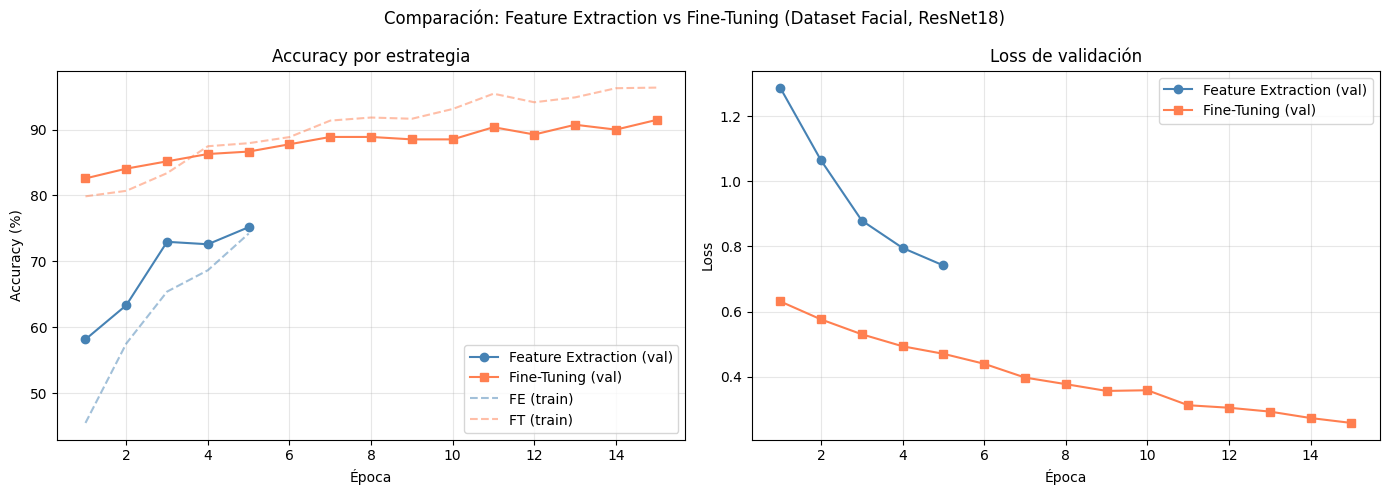


Resumen final:
  Feature Extraction: val acc = 75.2%
  Fine-Tuning:        val acc = 91.5%
  Mejora:             16.3 puntos porcentuales


In [20]:
import matplotlib.pyplot as plt

# Comparación Feature Extraction vs Fine-Tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas_fe = range(1, len(hist_fe["val_acc"]) + 1)
epocas_ft = range(1, len(hist_ft["val_acc"]) + 1)

# Accuracy
ax = axes[0]
ax.plot(epocas_fe, hist_fe["val_acc"],  "o-", color="steelblue",  label="Feature Extraction (val)")
ax.plot(epocas_ft, hist_ft["val_acc"], "s-", color="coral",      label="Fine-Tuning (val)")
ax.plot(epocas_fe, hist_fe["train_acc"], "--", color="steelblue",  alpha=0.5, label="FE (train)")
ax.plot(epocas_ft, hist_ft["train_acc"],"--", color="coral",      alpha=0.5, label="FT (train)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy por estrategia"); ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epocas_fe, hist_fe["val_loss"],   "o-", color="steelblue", label="Feature Extraction (val)")
ax.plot(epocas_ft, hist_ft["val_loss"],  "s-", color="coral",     label="Fine-Tuning (val)")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Loss de validación"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Comparación: Feature Extraction vs Fine-Tuning (Dataset Facial, ResNet18)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nResumen final:")
print(f"  Feature Extraction: val acc = {hist_fe['val_acc'][-1]:.1f}%")
print(f"  Fine-Tuning:        val acc = {hist_ft['val_acc'][-1]:.1f}%")
print(f"  Mejora:             {hist_ft['val_acc'][-1] - hist_fe['val_acc'][-1]:.1f} puntos porcentuales")